# **TASK 1: BIG DATA ANALYSIS USING PYSPARK**

Analysis of Netflix Movies and TV Shows Dataset using PySpark to demonstrate scalability and extract meaningful insights.

# **Import and Load Data**

In [1]:
!pip install pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("NetflixAnalysis").getOrCreate()

df = spark.read.csv("netflix_titles.csv", header=True, inferSchema=True)
df.show(5)

+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|      country|        date_added|release_year|rating| duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|     s1|  Movie|Dick Johnson Is Dead|Kirsten Johnson|                NULL|United States|September 25, 2021|        2020| PG-13|   90 min|       Documentaries|As her father nea...|
|     s2|TV Show|       Blood & Water|           NULL|Ama Qamata, Khosi...| South Africa|September 24, 2021|        2021| TV-MA|2 Seasons|International TV ...|After crossing pa...|
|     s3|TV Show|           Ganglands|Julien Leclercq|Sami Bouajila, Tr...|         NULL|Septem

# **Data Preprocessing**

In [2]:
from pyspark.sql.functions import col, sum

df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
|      0|   1|    2|    2636| 826|    832|        13|           2|     6|       5|        3|          3|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+



In [3]:
df = df.dropna(subset=["type", "country", "release_year"])

In [4]:
df = df.dropDuplicates()

In [5]:
df = df.withColumn("country", col("country"))

# **EDA(Exploratory Data Analysis)**

In [6]:
df.groupBy("type").count().show()  # Movie vs TV show

+-------------+-----+
|         type|count|
+-------------+-----+
|      TV Show| 2285|
|        Movie| 5691|
|William Wyler|    1|
+-------------+-----+



+--------------+-----+
|       country|count|
+--------------+-----+
| United States| 2805|
|         India|  972|
|United Kingdom|  419|
|         Japan|  245|
|   South Korea|  199|
|        Canada|  181|
|         Spain|  145|
|        France|  123|
|        Mexico|  110|
|         Egypt|  106|
+--------------+-----+
only showing top 10 rows


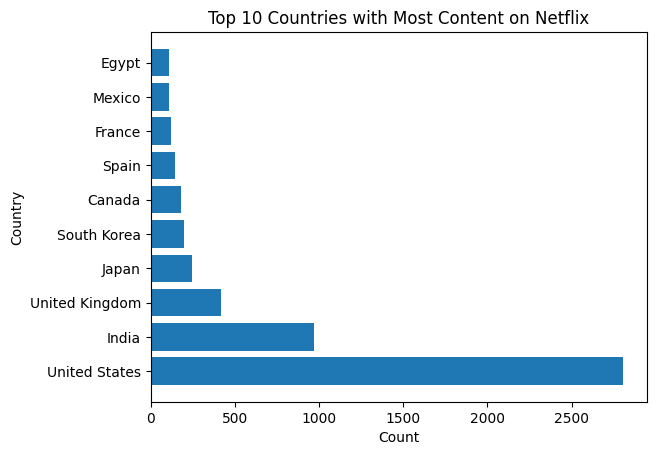

In [12]:
df.groupBy("country").count().orderBy("count", ascending=False).show(10)  # Top Countries

top_countries = df.groupBy("country").count().orderBy("count", ascending=False).limit(10).toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_countries["country"], top_countries["count"])
plt.title("Top 10 Countries with Most Content on Netflix")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

+-----------------+-----+
|     release_year|count|
+-----------------+-----+
|   Charles Rocket|    1|
|          Dr. Dre|    1|
|   Francis Weddey|    1|
|     Imanol Arias|    1|
|      Jade Eshete|    1|
| Kristen Johnston|    1|
| Marquell Manning|    1|
|       Nick Kroll|    1|
|    Nse Ikpe-Etim|    1|
|       Paul Sambo|    1|
|   Peter Ferriero|    1|
|     Ted Ferguson|    1|
| Álvaro Cervantes|    1|
|             1942|    2|
|             1943|    3|
|             1944|    2|
|             1945|    4|
|             1946|    2|
|             1947|    1|
|             1954|    2|
+-----------------+-----+
only showing top 20 rows


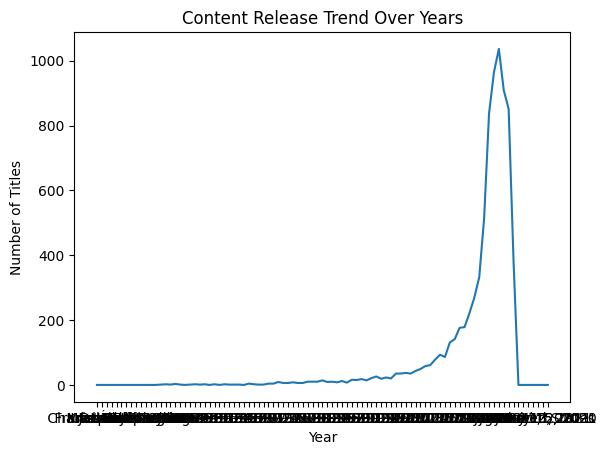

In [13]:
df.groupBy("release_year").count().orderBy("release_year").show()  # year wise content

year_data = df.groupBy("release_year").count().orderBy("release_year").toPandas()

plt.figure()
plt.plot(year_data["release_year"], year_data["count"])
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

+----------------+-----+
|          rating|count|
+----------------+-----+
|   Adriane Lenox|    1|
|            TV-Y|  227|
|            2019|    1|
|              UR|    3|
|            NULL|    3|
|              PG|  280|
|     Jide Kosoko|    1|
|           TV-MA| 2920|
| Jowharah Jones"|    1|
|        TV-Y7-FV|    5|
|          84 min|    1|
|              NR|   80|
|           TV-PG|  772|
| Richard Pepple"|    1|
|               R|  785|
|               G|   41|
|            2021|    2|
|           TV-14| 1928|
|            TV-G|  190|
| Kristen Schaal"|    1|
+----------------+-----+
only showing top 20 rows


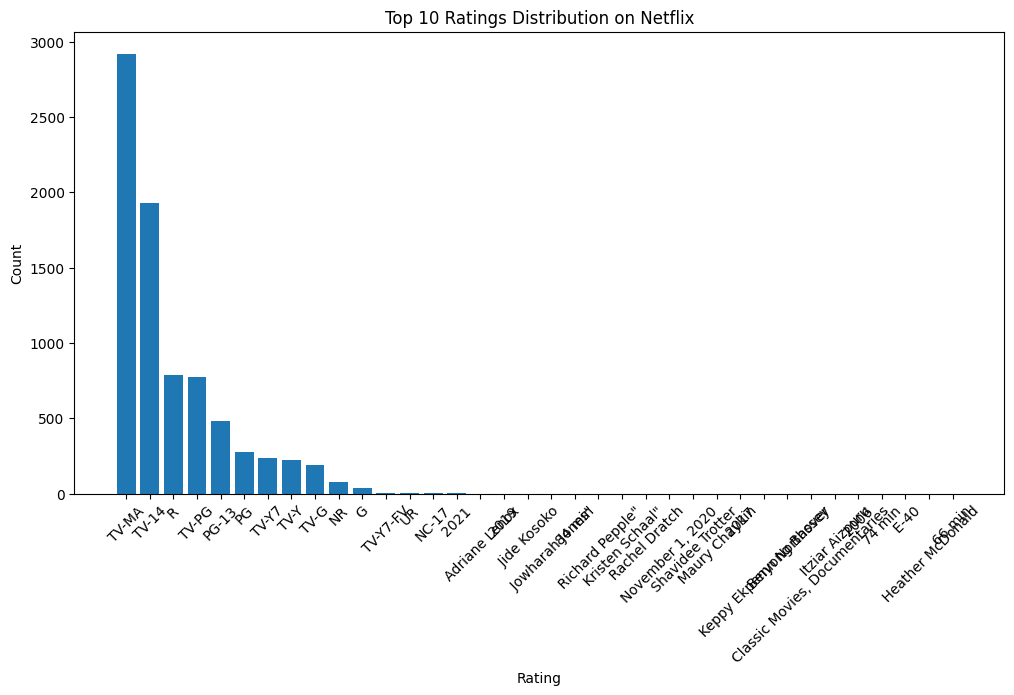

In [16]:
df.groupBy("rating").count().show()  # Ratings Distribution

df_clean = df.filter(col("rating").isNotNull())
rating_data = df_clean.groupBy("rating").count().orderBy("count", ascending=False)
rating_pd = rating_data.toPandas()
rating_pd = rating_pd.dropna()

plt.figure(figsize=(12,6))
plt.bar(rating_pd["rating"], rating_pd["count"])
plt.title("Top 10 Ratings Distribution on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# **Visualization**

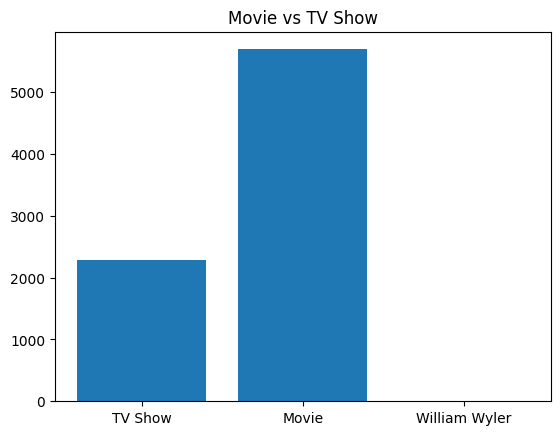

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

pdf = df.groupBy("type").count().toPandas()
plt.bar(pdf["type"], pdf["count"])
plt.title("Movie vs TV Show")
plt.show()

# **Introduction:**
This project focuses on analyzing a large dataset of Netflix movies and TV shows using PySpark. The goal is to perform scalable data processing and extract useful insights.
# **Data Loading:**
The dataset is loaded using PySpark to handle large-scale data efficiently.
# **Data Preprocessing:**
In this step, missing values are handled, and duplicate records are removed to ensure clean data for analysis.
# **Exploratory Data Analysis (EDA):**
Various analyses are performed to understand the dataset, including distribution of content types, countries, ratings, and release trends.
# **Data Visualization:**
Graphs and charts are used to visually represent the insights derived from the dataset.

# **INSIGHTS FROM NETFLIX DATA ANALYSIS**

1. The dataset shows that Movies are more available on Netflix compared to TV Shows.

2. The United States has the highest number of content available on Netflix, followed by other countries.

3. There is a significant increase in content production after 2015, with peak growth observed between 2018 and 2020.

4. The most common rating category on Netflix is TV-MA, indicating that a large portion of content is intended for mature audiences.

5. The analysis demonstrates how content distribution varies across countries, categories, and years, providing useful insights into Netflix's content strategy.